In [0]:
!pip install --verbose --disable-pip-version-check --no-cache-dir xgboost

Using pip 24.0 from /local_disk0/.ephemeral_nfs/envs/pythonEnv-753477b0-ed97-40fa-a3c0-7a679a8c2d1f/lib/python3.12/site-packages/pip (python 3.12)
  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/6c/9c/9d4ad7f586698bad52a570d2bf81138e500a5d9f32723c2b4ed1dd9252d8/xgboost-3.1.3-py3-none-manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for nvidia-nccl-cu12 from https://files.pythonhosted.org/packages/23/2d/609d0392d992259c6dc39881688a7fc13b1397a668bc360fbd68d1396f85/nvidia_nccl_cu12-2.29.2-py3-none-manylinux_2_18_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/115.9 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/115.9 MB 1.2 MB/s eta 0:01:37
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.2/115.9 MB 3.0 MB/s eta 0:00:39
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.5/115.9 MB 5.3 MB/s eta 0:00:22
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/115.9 MB 9.5 MB/s eta 0:00:13
   ━╺━━━━━━━━━━━━

In [0]:
symbol_list = ['ORCL', 'NFLX', 'MSFT', 'NOW', 'AAPL', 'META', 'ADBE', 'AVGO', 'DPZ', 'AMZN', "GOOGL"]
symbol_use = 'GOOGL'
symbol_use = 'NFLX'
start_date = '2023-01-01'

In [0]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
df = pd.read_csv('current_sp500_technical_factors.csv')
df.head()


,Unnamed: 0,symbol,date,open,high,low,close,adjusted_close,volume,sector,subIndustry,dist_sma_20,dist_sma_50,dist_sma_200,sma_dist_20_50,rsi_9,rsi_14,rsi_21,bb_width,bb_percent_b,bb_width_pctl,bb_squeeze,relative_volume,macd_hist_12_26_9,macd_line_12_26,macd_signal_9,momentum_raw,volatility,momentum_score,plus_di_14,minus_di_14,adx_14,stoch_k_14,stoch_d_3,stoch_low_14,stoch_high_14,vpt
0,0,AAPL,1995-01-03,38.8752,38.8752,37.8784,38.3712,0.2845,103868800,Information Technology,"Technology Hardware, Storage & Peripherals",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,AAPL,1995-01-04,38.6288,39.6256,38.6288,39.3792,0.2919,158681600,Information Technology,"Technology Hardware, Storage & Peripherals",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.000472,0.000590,0.000118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.127395e+06
2,2,AAPL,1995-01-05,39.2448,39.3792,38.7520,38.8752,0.2882,73640000,Information Technology,"Technology Hardware, Storage & Peripherals",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.000506,0.000751,0.000245,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.193966e+06
3,3,AAPL,1995-01-06,41.6304,43.1200,41.1264,42.0000,0.3114,1076622400,Information Technology,"Technology Hardware, Storage & Peripherals",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.001979,0.002719,0.000739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.986170e+07
4,4,AAPL,1995-01-09,41.6304,41.8768,41.0032,41.2048,0.3055,274086400,Information Technology,"Technology Hardware, Storage & Peripherals",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.002416,0.003759,0.001343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.466866e+07


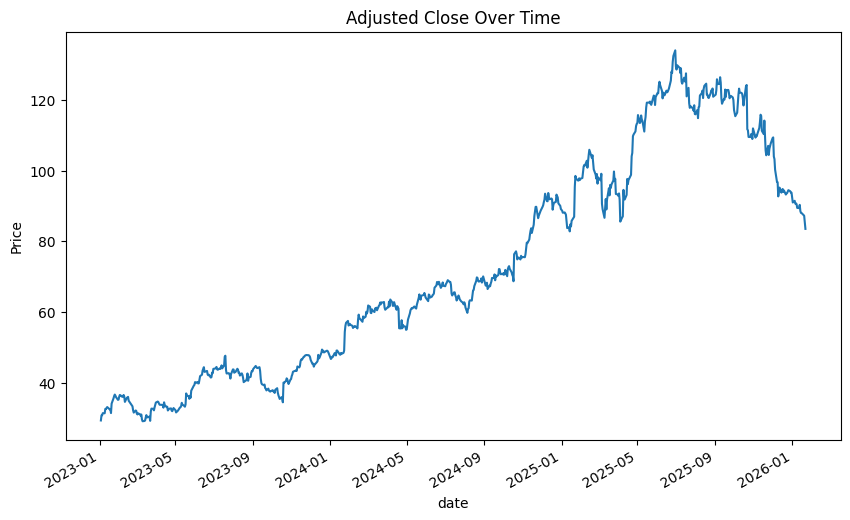

In [0]:
import matplotlib.pyplot as plt# 1. Ensure the date column is in datetime format

df_use = df[df['symbol'] == symbol_use]
df_use = df_use[df_use['date']>start_date]
df_use['date'] = pd.to_datetime(df_use['date'])

# 2. Set the date as the index
df_use.set_index('date', inplace=True)

# 3. Plot the specific column
df_use['adjusted_close'].plot(figsize=(10, 6), title='Adjusted Close Over Time')
plt.ylabel('Price')
plt.show()

In [0]:
# 1. Load your data
# df = pd.read_csv('your_technical_factors.csv')

# 2. Filter for MSFT and sort by date
df_msft = df[df['symbol'] == symbol_use].sort_values('date').copy()
df_msft = df_msft[df_msft['date']>start_date]

# 3. Create Target: 5-day forward return is positive?
# Shift close price back by 5 periods to look into the "future"
df_msft['future_close'] = df_msft['close'].shift(-5)
df_msft['return_5d'] = (df_msft['future_close'] - df_msft['close']) / df_msft['close']
df_msft['target'] = (df_msft['return_5d'] > 0).astype(int)

# 4. Define Features (Technical Factors)
# features = [
#     'open', 'high', 'low', 'close', 'adjusted_close', 'volume',
#     'dist_sma_20', 'dist_sma_50', 'dist_sma_200', 'sma_dist_20_50',
#     'rsi_9', 'rsi_14', 'rsi_21', 'bb_width', 'bb_percent_b', 
#     'bb_width_pctl', 'bb_squeeze', 'relative_volume', 'macd_hist_12_26_9',
#     'macd_line_12_26', 'macd_signal_9', 'momentum_raw', 'volatility',
#     'momentum_score', 'plus_di_14', 'minus_di_14', 'adx_14', 
#     'stoch_k_14', 'stoch_d_3', 'stoch_low_14', 'stoch_high_14', 'vpt'
# ]

features = ['volume','dist_sma_20', 'dist_sma_50', 'dist_sma_200', 'sma_dist_20_50',
    'rsi_9', 'rsi_14', 'rsi_21', 'bb_width', 'bb_percent_b', 
    'bb_width_pctl', 'bb_squeeze', 'relative_volume', 'macd_hist_12_26_9',
    'macd_line_12_26', 'macd_signal_9', 'momentum_raw', 'volatility',
    'momentum_score', 'plus_di_14', 'minus_di_14', 'adx_14', 
    'stoch_k_14', 'stoch_d_3', 'stoch_low_14', 'stoch_high_14', 'vpt'
]

# Drop rows with NaN (caused by shifting and indicator windows)
df_msft = df_msft.dropna(subset=['target'] + features)

X = df_msft[features]
y = df_msft['target']

# 5. Train/Test Split (Use shuffle=False for time-series data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 6. Initialize and Train XGBoost
model = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    n_estimators=10,     # Limit total trees
    max_depth=3,          # Shallow trees are harder to overfit
    learning_rate=0.05,   # Slow down learning to find better local minima
    subsample=0.7,        # Use only 70% of rows for each tree
    colsample_bytree=0.7, # Use only 70% of features for each tree
    gamma=1,              # Minimum loss reduction to split
    reg_lambda=2          # Increase L2 regularization
)

model.fit(X_train, y_train)

# Get predictions for the training set
train_preds = model.predict(X_train)

# Evaluate training performance
print(f"Training Accuracy: {accuracy_score(y_train, train_preds):.2f}")
print("Training Classification Report:")
print(classification_report(y_train, train_preds))

# 7. Evaluate
preds = model.predict(X_test)
print(f"Testing Accuracy: {accuracy_score(y_test, preds):.2f}")
print(classification_report(y_test, preds))

Training Accuracy: 0.68
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.22      0.36       250
           1       0.65      1.00      0.79       362

    accuracy                           0.68       612
   macro avg       0.82      0.61      0.57       612
weighted avg       0.79      0.68      0.61       612

Testing Accuracy: 0.42
              precision    recall  f1-score   support

           0       1.00      0.07      0.13        97
           1       0.39      1.00      0.56        57

    accuracy                           0.42       154
   macro avg       0.69      0.54      0.35       154
weighted avg       0.77      0.42      0.29       154



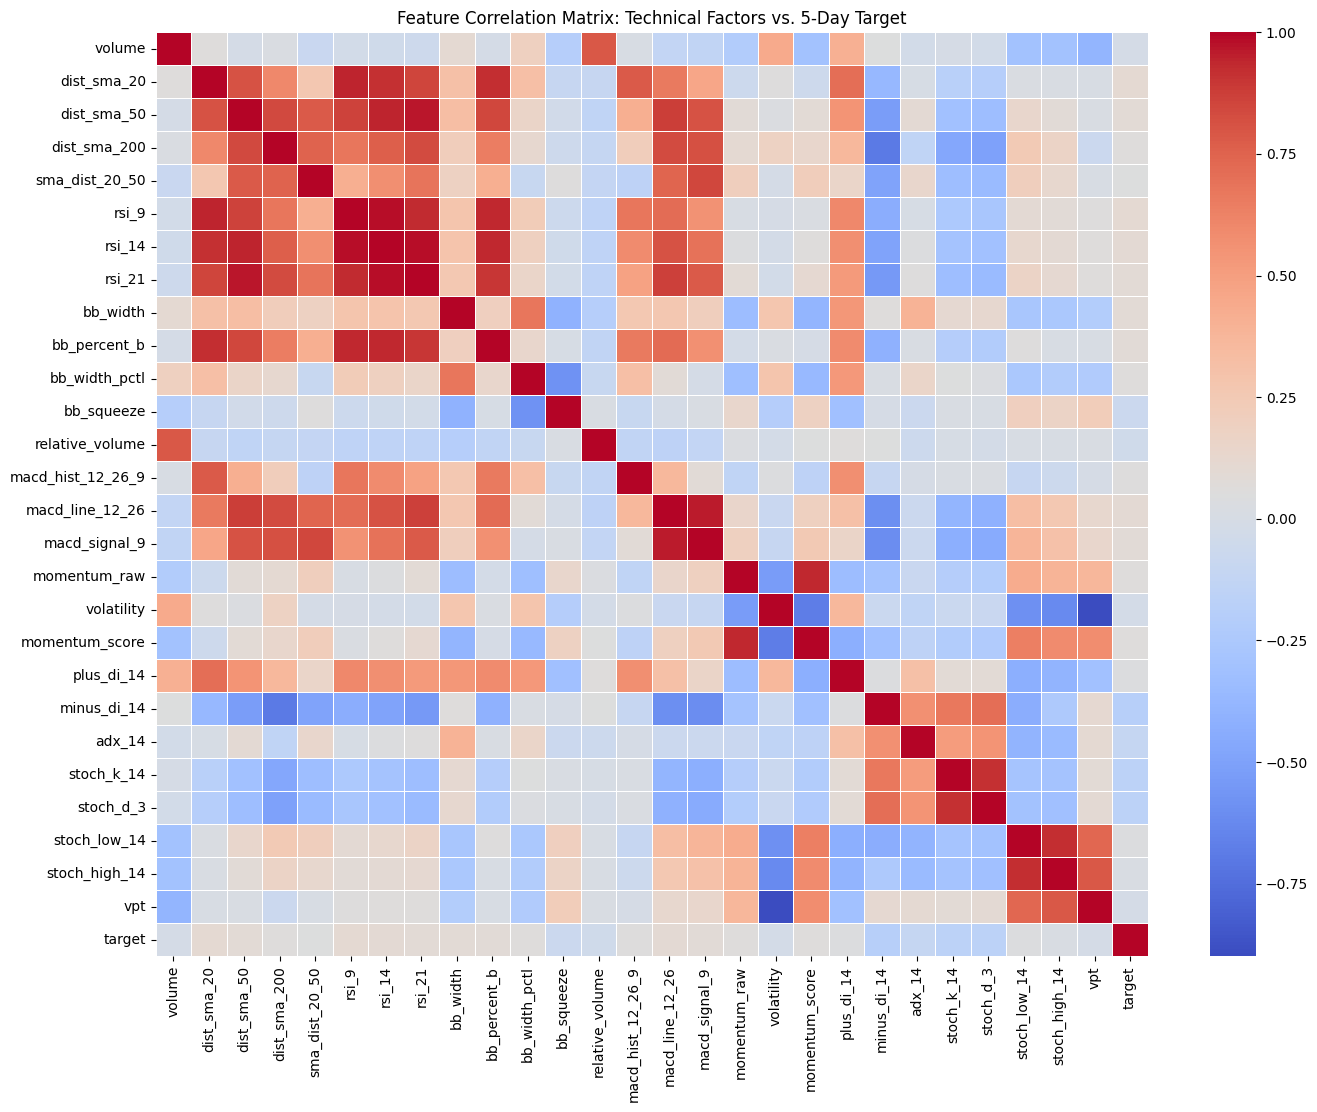

Top Correlations with Target:
target             1.000000
rsi_9              0.106003
dist_sma_20        0.104653
rsi_14             0.100261
macd_line_12_26    0.096708
rsi_21             0.093690
dist_sma_50        0.092838
bb_width           0.089131
macd_signal_9      0.086271
bb_percent_b       0.082348
Name: target, dtype: float64


In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix
# We include the 'target' to see which features have the most 'predictive' hint
corr_matrix = df_msft[features + ['target']].corr()

# 2. Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix, 
    annot=False,          # Set to True if you want to see the exact numbers
    cmap='coolwarm',      # Red is positive correlation, Blue is negative
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix: Technical Factors vs. 5-Day Target")
plt.show()

# 3. Identify top features for the target specifically
target_corr = corr_matrix['target'].sort_values(ascending=False)
print("Top Correlations with Target:")
print(target_corr.head(10))

In [0]:
# from sklearn.feature_selection import mutual_info_classif
# import pandas as pd
# import matplotlib.pyplot as plt

# def calculate_rolling_mi(df, features, target_col, window=60, step=5):
#     mi_results = []
#     dates = []
    
#     # Iterate through the dataframe in steps
#     for i in range(window, len(df), step):
#         window_df = df.iloc[i-window:i]
#         X_window = window_df[features]
#         y_window = window_df[target_col]
        
#         # Calculate MI for all features in this window
#         mi_scores = mutual_info_classif(X_window, y_window, discrete_features=False, random_state=42)
        
#         mi_results.append(mi_scores)
#         dates.append(df.iloc[i]['date'])
        
#     return pd.DataFrame(mi_results, index=dates, columns=features)

# # 1. Select your top 5 suspect features
# top_5_features = ['rsi_14', 'volatility', 'adx_14', 'bb_width', 'relative_volume']

# # 2. Run the rolling MI (using a 60-trading-day window)
# mi_history = calculate_rolling_mi(df_msft, top_5_features, 'target', window=60)

# # 3. Plot the results
# plt.figure(figsize=(14, 7))
# for col in top_5_features:
#     plt.plot(mi_history.index, mi_history[col], label=col)

# plt.title("MSFT: Rolling Mutual Information (60-Day Window)")
# plt.ylabel("Information Gain (Bits)")
# plt.xlabel("Date")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()


In [0]:
# X_train.head()

In [0]:
# df_msft.head()

ROC AUC Score: 0.3997


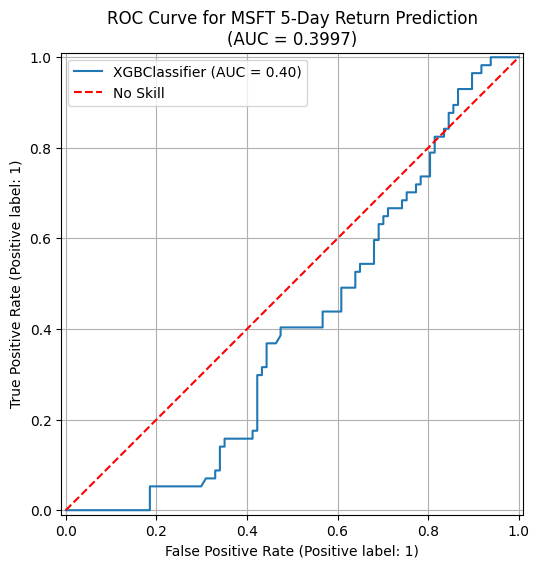

In [0]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# 1. Get predicted probabilities for the positive class (class 1)
# model.predict_proba returns [prob_class_0, prob_class_1]
y_probs = model.predict_proba(X_test)[:, 1]

# 2. Calculate Area Under the Curve (AUC)
auc_score = roc_auc_score(y_test, y_probs)
print(f"ROC AUC Score: {auc_score:.4f}")

# 3. Plot the ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)

# Add a 'No Skill' dashed line for reference
ax.plot([0, 1], [0, 1], linestyle='--', color='red', label='No Skill')

ax.set_title(f"ROC Curve for MSFT 5-Day Return Prediction\n(AUC = {auc_score:.4f})")
plt.legend()
plt.grid(True)
plt.show()

In [0]:

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Prepare Target Variable
# Calculate return for the next 5 trading days (approx. 1 week)
df['target'] = (df['close'].shift(-5) > df['close']).astype(int)

# 2. Select Features (Removing non-predictive or target-related columns)
features = [
    'dist_sma_20', 'dist_sma_50', 'dist_sma_200', 'sma_dist_20_50',
    'rsi_9', 'rsi_14', 'rsi_21', 'bb_width', 'bb_percent_b', 
    'bb_width_pctl', 'bb_squeeze', 'relative_volume', 'macd_hist_12_26_9',
    'macd_line_12_26', 'macd_signal_9', 'momentum_raw', 'volatility',
    'momentum_score', 'plus_di_14', 'minus_di_14', 'adx_14',
    'stoch_k_14', 'stoch_d_3', 'stoch_low_14', 'stoch_high_14', 'vpt'
]

# Handle Categorical Features (Sector/SubIndustry)
df = pd.get_dummies(df, columns=['sector', 'subIndustry'])
features += [col for col in df.columns if 'sector_' in col or 'subIndustry_' in col]

# 3. Clean and Split Data
# Remove the last 5 rows because they won't have a future target
data = df.dropna(subset=['target']).copy()
X = data[features]
y = data['target']

# Time-series split: No shuffling to maintain chronological order
split = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# 4. Train XGBoost
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
